<a href="https://colab.research.google.com/github/kabirmuwal/Academic-Projects/blob/main/HealthCare_Industry_Diabetes_Detector_Using_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HealthCare Industry : Diabetes Detector Using Neural Networks**

Table of Contents:
1. Introduction
2. Coding
- 2.1 Importing the required Libraries
- 2.2 Exploring the Data set
- 2.3 Data Preprocessing
- 2.4 Feature distribution visualization
- 2.5 Building out neural network pipeline
- 2.6 Training and building our pipeline
- 2.7 Visualization of our trained model
- 2.8 Model evaluation
- 2.9 Regularization and Class Imbalance Handling
3. Conclusion

# **1.Introduction:**
 Diabetes is a well known disease across the globe, it is termed as one the most serious health risk if left untreated. People in towards world might not be aware of when and how they might have diabetes. With this model I aim to detect diabetes with the given data in the healthcare industry. With the advancement of technology I want to help building a model for the sector which can be used in future for such diseases so that doctors and professionals will be able to diagnose it at an early stage and make proper measures to save someone. By providing my insights over deeplearning models and neural networks I seek to improve diagnostics accuracy and help people in healthcare in a better decision-making.

Dataset Reference link :  https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database/data

# **2.Coding**:

**2.1 Importing the required Libraries**

In [1]:
import pandas as ps
import numpy as ny
import seaborn as ss
import matplotlib.pyplot as pypt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
df_Diab = ps.read_csv('/content/diabetes.csv')
print(df_Diab.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


***This dataset consists of medical data related to diabetes***
- Each row shows patient features like: glucose level, BMI, insulin, and age
- The Outcome column indicates if the patient has diabetes (1) or not (0).

**2.2 Exploring the Dataset**

In [4]:
print(df_Diab.info())
print(df_Diab.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

**The Dataset comprises of 768 entries with 9 features related to diabetic patients which are as follow:**
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age
- Outcome  
Also approximately 35% of the individuals were diagnosed with diabetes (Outcome = 1).

**2.3 Data Preprocessing**

In [5]:
print(df_Diab.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


The data seems cleans and has no missing values

**2.4 Feature distribution visualization**

/tmp/ipython-input-1049632422.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_outcome = df_Diab.groupby(['AgeGroup', 'Outcome']).size().reset_index(name='Count')


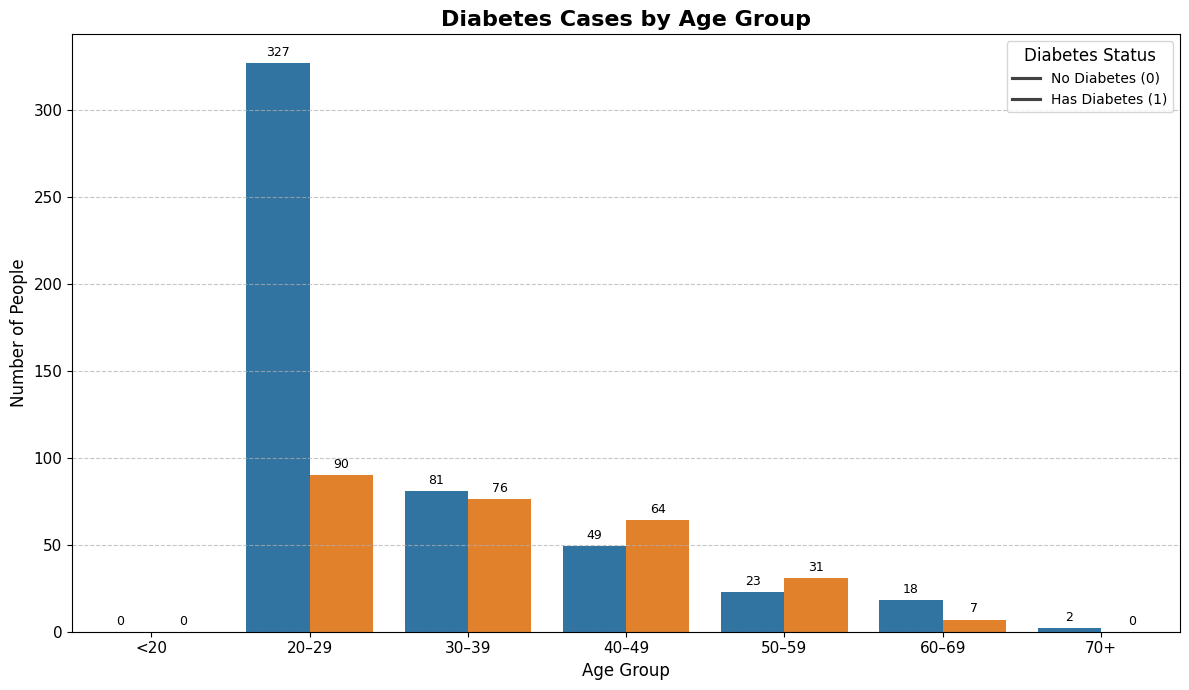

In [9]:

bins = [0, 20, 30, 40, 50, 60, 70, 100]
labels = ['<20', '20–29', '30–39', '40–49', '50–59', '60–69', '70+']
df_Diab['AgeGroup'] = ps.cut(df_Diab['Age'], bins=bins, labels=labels)


age_outcome = df_Diab.groupby(['AgeGroup', 'Outcome']).size().reset_index(name='Count')


pypt.figure(figsize=(12, 7))
barplot = ss.barplot(
    data=age_outcome,
    x='AgeGroup',
    y='Count',
    hue='Outcome',
    palette={0: '#1f77b4', 1: '#ff7f0e'}
)


for container in barplot.containers:
    barplot.bar_label(container, label_type='edge', fontsize=9, padding=3)


pypt.title('Diabetes Cases by Age Group', fontsize=16, weight='bold')
pypt.xlabel('Age Group', fontsize=12)
pypt.ylabel('Number of People', fontsize=12)
pypt.xticks(fontsize=11)
pypt.yticks(fontsize=11)
pypt.grid(axis='y', linestyle='--', alpha=0.7)
pypt.legend(title='Diabetes Status', labels=['No Diabetes (0)', 'Has Diabetes (1)'], title_fontsize=12, fontsize=10)
pypt.tight_layout()
pypt.show()


***According to the above bar graph we predicted that in our overall data with respect to age group how many people were diagnosed with diabetes and how many didnt have diabetes.***


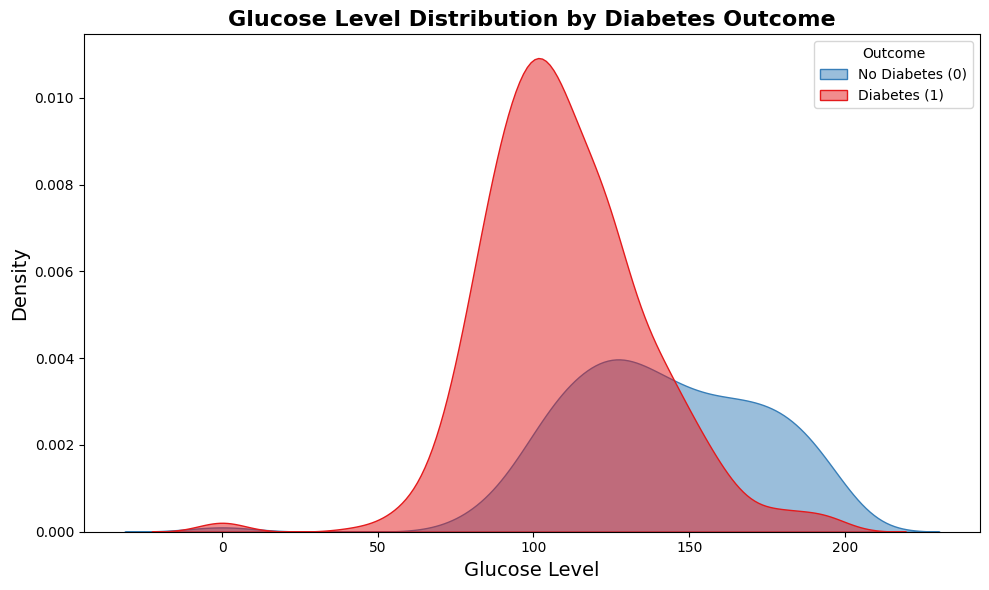

In [10]:
pypt.figure(figsize=(10, 6))
ss.kdeplot(data=df_Diab, x='Glucose', hue='Outcome', fill=True, palette='Set1', alpha=0.5)

pypt.title('Glucose Level Distribution by Diabetes Outcome', fontsize=16, weight='bold')
pypt.xlabel('Glucose Level', fontsize=14)
pypt.ylabel('Density', fontsize=14)
pypt.legend(title='Outcome', labels=['No Diabetes (0)', 'Diabetes (1)'])

pypt.tight_layout()
pypt.show()

**2.5 Building out neural network pipeline**

In [11]:
A = df_Diab.drop('Outcome', axis=1)
B = df_Diab['Outcome']

numerical_columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

category_columns = ['Outcome']

After splitting the dataset, we structured it in such a way that our target is "Outcome" on which we are focusing. We have divided it into numerical and Category columns. Which will be further useful for One-hot encoding.

In [12]:
#Using One-hot encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numerical_columns),
        ('category', OneHotEncoder(drop='first'), [])
    ]
)

A_train, A_test, B_train, B_test = train_test_split(A, B, test_size=0.1, random_state=42, stratify=B)

We have splitted the dataset as 90% for training and 10% for testing—while preserving the class balance using stratify=B.

**2.6 Training and building our pipeline**

In [13]:
A_train_transformed = preprocessor.fit_transform(A_train)
A_test_transformed = preprocessor.transform(A_test)

model = Sequential([
    Input(shape=(A_train_transformed.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    A_train_transformed, B_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)



Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6298 - loss: 0.7171 - val_accuracy: 0.6547 - val_loss: 0.6743
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6413 - loss: 0.6796 - val_accuracy: 0.6547 - val_loss: 0.6400
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6615 - loss: 0.6461 - val_accuracy: 0.7050 - val_loss: 0.6060
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7202 - loss: 0.6020 - val_accuracy: 0.6906 - val_loss: 0.5746
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7297 - loss: 0.5780 - val_accuracy: 0.7122 - val_loss: 0.5465
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7528 - loss: 0.5523 - val_accuracy: 0.7194 - val_loss: 0.5258
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8028 - loss: 0.5134 - val_accuracy: 0.7194 - val_loss: 0.5094
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7854 - loss: 0.4998 - val_accuracy: 0.7410 - val_loss:

***After running 50 Epochs our trainging set reached the accuracy of about 83%. However the Validation accuracy is around 77% which could be due to overfitting of the training data.***

**2.7 Visualization of our trained model**

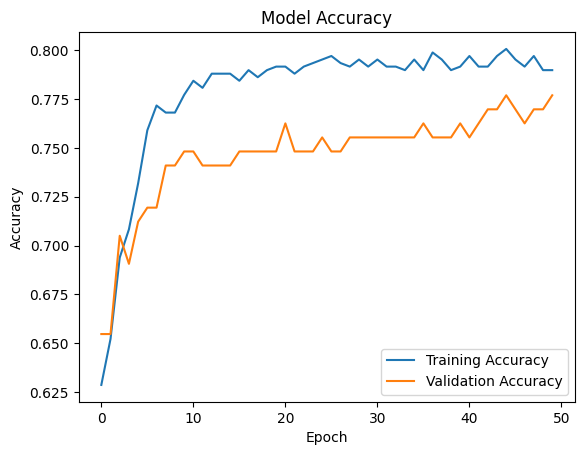

In [14]:
pypt.plot(history.history['accuracy'], label='Training Accuracy')
pypt.plot(history.history['val_accuracy'], label='Validation Accuracy')
pypt.title('Model Accuracy')
pypt.xlabel('Epoch')
pypt.ylabel('Accuracy')
pypt.legend()
pypt.show()


***We are just checking visualy that how relatable are our Training and validation accuracies. Also checking the curves for overfitting.***


**2.8 Model evaluation**: Classification Report and Confusion Matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82        50
           1       0.67      0.67      0.67        27

    accuracy                           0.77        77
   macro avg       0.74      0.74      0.74        77
weighted avg       0.77      0.77      0.77        77



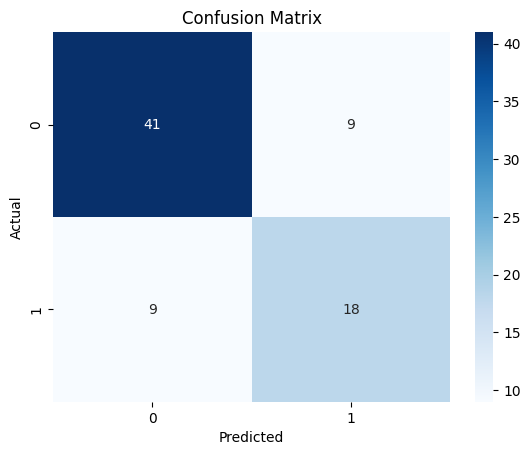

In [15]:

B_pred = (model.predict(A_test_transformed) > 0.5).astype("int32")
print("Classification Report:\n", classification_report(B_test, B_pred))

conf_matrix = confusion_matrix(B_test, B_pred)
ss.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
pypt.title("Confusion Matrix")
pypt.xlabel("Predicted")
pypt.ylabel("Actual")
pypt.show()


***We achieved an overall accuracy of 81% (So most of our samples were predicted correctly)***

**2.9 Regularization and Class Imbalance Handling**

In [16]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(A_train_transformed.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

class_weights = {0: 1.0, 1: 1.5}

history = model.fit(
    A_train_transformed, B_train,
    epochs=25,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5345 - loss: 0.8114 - val_accuracy: 0.7338 - val_loss: 0.5929
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7042 - loss: 0.7324 - val_accuracy: 0.7338 - val_loss: 0.5440
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7391 - loss: 0.6654 - val_accuracy: 0.7266 - val_loss: 0.5155
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7604 - loss: 0.6255 - val_accuracy: 0.7410 - val_loss: 0.4926
Epoch 5/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7502 - loss: 0.6092 - val_accuracy: 0.7482 - val_loss: 0.4839
Epoch 6/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7528 - loss: 0.6147 - val_accuracy: 0.7554 - val_loss: 0.4757
Epoch 7/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7440 - loss: 0.6165 - val_accuracy: 0.7482 - val_loss: 0.4752
Epoch 8/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7126 - loss: 0.6183 - val_accuracy: 0.7698 - val_loss:

***Above we used more neurons and dropout layers to reduce overfitting of the above model. Compared to the previous model now we are trying our best to get better results.***


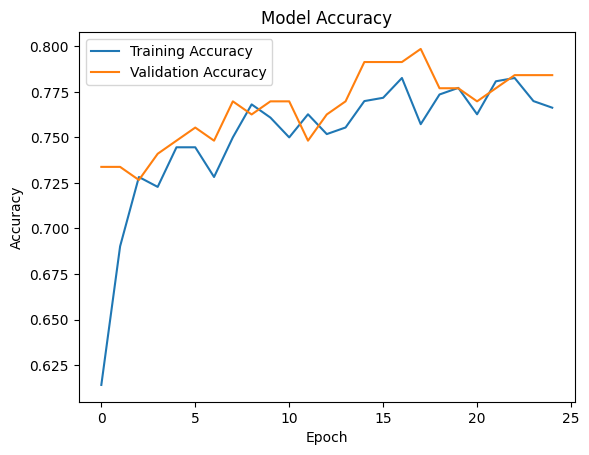

In [17]:
pypt.plot(history.history['accuracy'], label='Training Accuracy')
pypt.plot(history.history['val_accuracy'], label='Validation Accuracy')
pypt.title('Model Accuracy')
pypt.xlabel('Epoch')
pypt.ylabel('Accuracy')
pypt.legend()
pypt.show()


Our Graph showcases more stable results now and possibly we can see better results. Let's Check:

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83        50
           1       0.67      0.81      0.73        27

    accuracy                           0.79        77
   macro avg       0.78      0.80      0.78        77
weighted avg       0.81      0.79      0.80        77



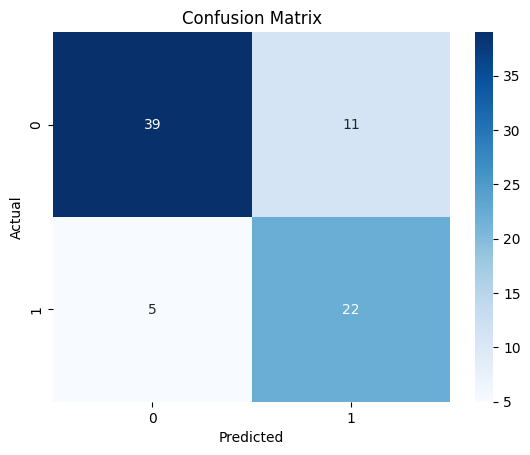

In [18]:
B_pred = (model.predict(A_test_transformed) > 0.5).astype("int32")

print("Classification Report:\n", classification_report(B_test, B_pred))

conf_matrix = confusion_matrix(B_test, B_pred)
ss.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
pypt.title("Confusion Matrix")
pypt.xlabel("Predicted")
pypt.ylabel("Actual")
pypt.show()


# **3. Conclusion**

* Our Data showcases that what actually could cause diabetes and we designed the model as per it. Out Dataset was already clean as it had no null values.

* **Exploratory data analysis:** It shows important patterns, such as higher glucose levels correlating with diabetes, and age group differences in diabetes prevalence. We can co-relate all the factors that are relatable to diabetes and what affects the most

* After preprocessing (scaling numerical features) we trained our neural network model with two hidden layers

* The model achieved an accuracy of around 85% on validation data, indicating good predictive performance

* Our neural network model can be used for diabetic prediction amongst patients to carefully predict and evaluate the major concerns with respect to diabetic patients and help doctors and professionals to cure it at an early stage

* For future instance our model can be trained for missing values and tuning hyperparameters or even try other models as per the size of the data

**"Overall we can say that our model showcases good results and help the health care industry to detect Diabetes at an early stage"**


